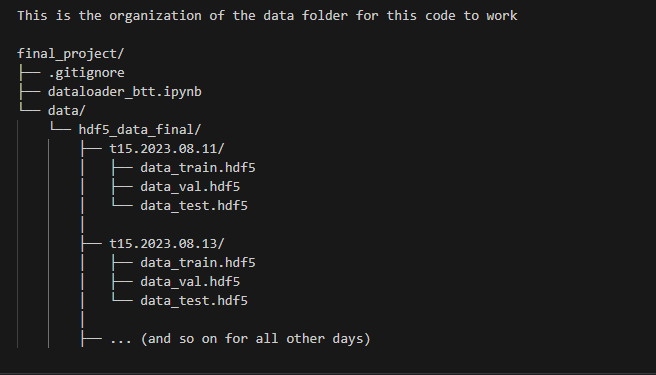

In [3]:
# offical website code to read .hdf5 files from Brain-to-Text
import h5py


def load_h5py_file(file_path):
    data = {
        "neural_features": [],
        "n_time_steps": [],
        "seq_class_ids": [],
        "seq_len": [],
        "transcriptions": [],
        "sentence_label": [],
        "session": [],
        "block_num": [],
        "trial_num": [],
    }
    # open the hdf5 file for that day
    with h5py.File(file_path, "r") as f:
        keys = list(f.keys())

        # each trail in the day
        for key in keys:
            g = f[key]

            neural_features = g["input_features"][:]
            n_time_steps = g.attrs["n_time_steps"]
            seq_class_ids = g["seq_class_ids"][:] if "seq_class_ids" in g else None
            seq_len = g.attrs["seq_len"] if "seq_len" in g.attrs else None
            transcription = g["transcription"][:] if "transcription" in g else None
            sentence_label = (
                g.attrs["sentence_label"][:] if "sentence_label" in g.attrs else None
            )
            session = g.attrs["session"]
            block_num = g.attrs["block_num"]
            trial_num = g.attrs["trial_num"]

            data["neural_features"].append(neural_features)
            data["n_time_steps"].append(n_time_steps)
            data["seq_class_ids"].append(seq_class_ids)
            data["seq_len"].append(seq_len)
            data["transcriptions"].append(transcription)
            data["sentence_label"].append(sentence_label)
            data["session"].append(session)
            data["block_num"].append(block_num)
            data["trial_num"].append(trial_num)
    return data


dtrain = load_h5py_file("data\hdf5_data_final\\t15.2023.08.11\data_train.hdf5")

In [4]:
print(dtrain.keys())

dict_keys(['neural_features', 'n_time_steps', 'seq_class_ids', 'seq_len', 'transcriptions', 'sentence_label', 'session', 'block_num', 'trial_num'])


In [5]:
dtrain["neural_features"][0].shape

(321, 512)

In [7]:
from pathlib import Path
import random


# read the .hdf5 files in a directory and its subdirectories by a specified percent_to_read (0-100)
def load_all_data_from_directory(base_directory, percent_to_read=100):
    base_path = Path(base_directory)
    all_hdf5_files = list(base_path.rglob("*.hdf5"))

    if not all_hdf5_files:
        print(f"No .hdf5 files found in '{base_path.resolve()}'")
        return None

    print(f"Found {len(all_hdf5_files)} files")

    if percent_to_read < 100:
        percent_to_read = max(0, min(100, percent_to_read))

        num_files_to_sample = int(len(all_hdf5_files) * (percent_to_read / 100.0))

        print(
            f"Found {len(all_hdf5_files)} total files. Randomly sampling {num_files_to_sample} files ({percent_to_read}%)..."
        )

        files_to_process = random.sample(all_hdf5_files, num_files_to_sample)
    else:
        print(f"Found {len(all_hdf5_files)} files. Processing all of them...")
        files_to_process = all_hdf5_files

    aggregated_data = {
        "neural_features": [],
        "n_time_steps": [],
        "seq_class_ids": [],
        "seq_len": [],
        "transcriptions": [],
        "sentence_label": [],
        "session": [],
        "block_num": [],
        "trial_num": [],
    }

    for file_path in files_to_process:
        print(f"Reading {file_path.name} from {file_path.parent.name}...")
        data_from_file = load_h5py_file(file_path)
        for key in aggregated_data.keys():
            aggregated_data[key].extend(data_from_file[key])

    print(f"\n Finished! Total trials loaded: {len(aggregated_data['trial_num'])}")
    return aggregated_data

In [8]:
load_all_data_from_directory("data\hdf5_data_final", percent_to_read=1)

Found 127 files
Found 127 total files. Randomly sampling 1 files (1%)...
Reading data_val.hdf5 from t15.2023.12.17...

 Finished! Total trials loaded: 30


{'neural_features': [array([[-0.26310498,  0.9753587 , -0.58253694, ..., -0.8794705 ,
           1.8164341 , -0.4781921 ],
         [-0.26310498, -0.50960886, -0.58253694, ...,  0.64632004,
          -0.45074534, -0.00493089],
         [-0.26310498,  0.9753587 , -0.58253694, ...,  1.3025581 ,
           0.5285948 ,  1.3731633 ],
         ...,
         [-0.26310498, -0.50960886, -0.58253694, ..., -0.7491034 ,
          -0.9512357 , -0.18901604],
         [-0.26310498, -0.50960886, -0.58253694, ...,  0.15105572,
          -0.7262144 ,  1.0386164 ],
         [-0.26310498, -0.50960886, -0.58253694, ...,  0.37267897,
          -0.65654445,  0.97259134]], dtype=float32),
  array([[-0.25635234, -0.5211894 , -0.5713001 , ..., -1.0731231 ,
          -1.3498542 ,  0.19516923],
         [-0.25635234,  2.3879373 , -0.5713001 , ..., -0.7206086 ,
           0.5458704 ,  1.6452043 ],
         [-0.25635234,  0.9333739 , -0.5713001 , ..., -1.3481616 ,
          -0.25135228, -1.4996543 ],
         ...,


In [ ]:
# if specify specific days, percent of days to read will be ignored
def load_data_by_day(base_directory, percent_of_days_to_read=100, specific_days=None):
    base_path = Path(base_directory)
    all_day_folders = [d for d in base_path.iterdir() if d.is_dir()]

    if not all_day_folders:
        print(f"No subdirectories found in '{base_path.resolve()}'")
        return None

    if specific_days is not None:
        if isinstance(specific_days, str):
            specific_days = [specific_days]
        folders_to_process = [d for d in all_day_folders if d.name in specific_days]
        print(f"Targeting {len(folders_to_process)} specific day(s): {specific_days}")
    else:
        if percent_of_days_to_read < 100:
            num_folders = int(len(all_day_folders) * (percent_of_days_to_read / 100.0))
            print(
                f"Found {len(all_day_folders)} total days. Randomly sampling {num_folders}"
            )
            folders_to_process = random.sample(all_day_folders, num_folders)
        else:
            print(f"Found {len(all_day_folders)} total days. Processing all...")
            folders_to_process = all_day_folders

    files_by_type = {"train": [], "val": [], "test": []}
    for folder in folders_to_process:
        for f in folder.glob("*.hdf5"):
            if "train" in f.name:
                files_by_type["train"].append(f)
            elif "val" in f.name:
                files_by_type["val"].append(f)
            elif "test" in f.name:
                files_by_type["test"].append(f)

    final_datasets = {}
    for data_type, file_list in files_by_type.items():
        if not file_list:
            print(f"No '{data_type}' files found in the selected days.")
            final_datasets[data_type] = None
            continue

        print(f"Processing {len(file_list)} '{data_type}' files")

        aggregated_data = {
            "neural_features": [],
            "n_time_steps": [],
            "seq_class_ids": [],
            "seq_len": [],
            "transcriptions": [],
            "sentence_label": [],
            "session": [],
            "block_num": [],
            "trial_num": [],
        }

        for file_path in file_list:
            data_from_file = load_h5py_file(file_path)
            for key in aggregated_data.keys():
                aggregated_data[key].extend(data_from_file[key])

        final_datasets[data_type] = aggregated_data

    print("\n Finished loading!")
    return final_datasets

In [10]:
base_directory = "data\hdf5_data_final"
load_data_by_day(
    base_directory, percent_of_days_to_read=100, specific_days="t15.2023.08.20"
)

Targeting 1 specific day(s): ['t15.2023.08.20']
Processing 1 'train' files
Processing 1 'val' files
Processing 1 'test' files

 Finished loading!


{'train': {'neural_features': [array([[-4.75748628e-01,  4.46838588e-01, -3.25115800e-01, ...,
           -3.75982463e-01, -9.89253700e-01,  3.88722983e-03],
          [-4.75748628e-01, -6.33314490e-01, -3.25115800e-01, ...,
           -1.10504842e+00, -6.77547336e-01, -7.95815885e-01],
          [-4.75748628e-01, -6.33314490e-01, -3.25115800e-01, ...,
           -3.36553395e-01,  1.50711393e+00, -6.86232388e-01],
          ...,
          [-4.75748628e-01, -6.33314490e-01,  1.89289653e+00, ...,
           -6.54904127e-01, -1.13012481e+00, -5.61984360e-01],
          [-4.75748628e-01, -6.33314490e-01,  6.32892132e+00, ...,
           -4.72864836e-01, -2.68994123e-01, -1.09310555e+00],
          [-4.75748628e-01, -6.33314490e-01, -3.25115800e-01, ...,
           -1.12065136e+00,  7.95356572e-01,  1.03044994e-01]], dtype=float32),
   array([[-0.46258363, -0.6735174 , -0.3380471 , ...,  0.51770097,
           -0.7632641 , -0.4929799 ],
          [-0.46258363, -0.6735174 , -0.3380471 , ...,

In [11]:
load_data_by_day(base_directory, percent_of_days_to_read=10)

Found 45 total days. Randomly sampling 4
Processing 4 'train' files
Processing 4 'val' files
Processing 4 'test' files

 Finished loading!


{'train': {'neural_features': [array([[-0.43282148, -0.5435369 , -0.41676447, ..., -0.8477099 ,
            0.30955726, -1.2425157 ],
          [-0.43282148, -0.5435369 , -0.41676447, ..., -0.7598753 ,
           -1.1957082 , -0.9934553 ],
          [ 1.4040186 , -0.5435369 , -0.41676447, ..., -0.3081824 ,
            0.19179608, -0.88845897],
          ...,
          [-0.43282148,  0.8385945 , -0.41676447, ..., -0.60481054,
           -1.1621227 , -1.2173214 ],
          [-0.43282148, -0.5435369 ,  3.4926336 , ..., -0.81665087,
            0.01123302,  0.55198574],
          [-0.43282148,  0.8385945 , -0.41676447, ...,  1.7301517 ,
           -0.92765653,  0.02990209]], dtype=float32),
   array([[-0.4200658 , -0.53628004, -0.41205987, ..., -0.72933453,
           -0.23815912, -1.1397609 ],
          [-0.4200658 , -0.53628004, -0.41205987, ..., -0.7462334 ,
            0.8886739 ,  1.3445338 ],
          [-0.4200658 , -0.53628004, -0.41205987, ...,  0.08416218,
           -0.48039216, 